# Riemann Problem

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from kuibit.simdir import SimDir
from kuibit.grid_data import UniformGrid

## Exact Solution

In [2]:
#initial data from the Exact Riemann solver of https://www.brunogiacomazzo.org/?page_id=395
exact = np.loadtxt("Sod_exact.dat")

In [3]:
x_exact=exact[:,0]
rho_exact=exact[:,1]
press_exact=exact[:,2] #note: this is pgas+pmag
vx_exact=exact[:,3]
vy_exact=exact[:,4]
vz_exact=exact[:,5]
By_exact=exact[:,6]
Bz_exact=exact[:,7]

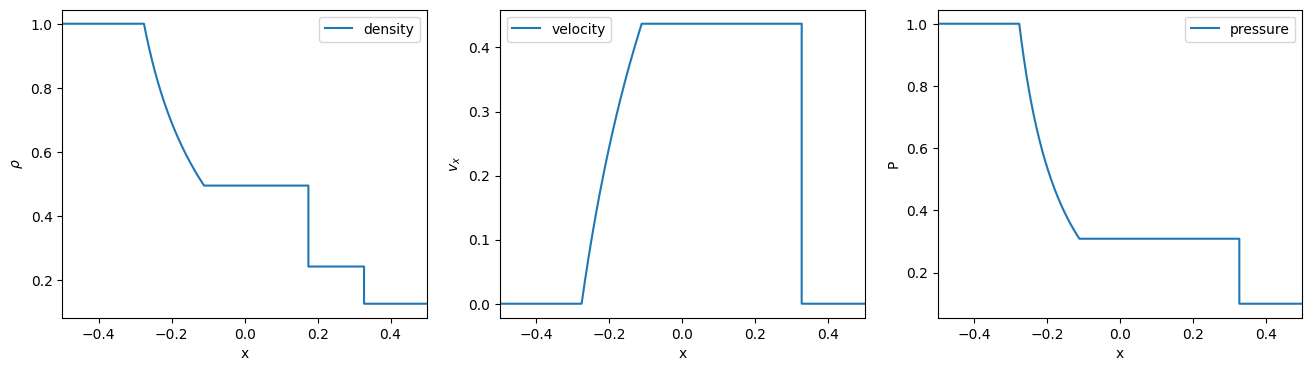

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(x_exact, rho_exact, label="density")
ax[0].set(xlim= [-0.5, 0.5], xlabel='x', ylabel=r'$\rho$')
ax[0].legend()

ax[1].plot(x_exact, vx_exact, label="velocity")
ax[1].set(xlim= [-0.5, 0.5], xlabel='x', ylabel=r'$v_x$')
ax[1].legend()

ax[2].plot(x_exact, press_exact, label="pressure")
ax[2].set(xlim= [-0.5, 0.5], xlabel='x', ylabel='P')
ax[2].legend()

plt.show()

## Read the Numerical Results

In [5]:
gf= SimDir("/home/lisa/simulations/Sod400/").gf
gf_800 = SimDir("/home/lisa/simulations/Sod800/").gf
print(gf_800)


Available grid data of dimension 1D (x): 
['vel[1]', 'rho', 'w_lorentz', 'tau', 'scon[2]', 'eps', 'press', 'vel[2]', 'scon[1]', 'vel[0]', 'scon[0]', 'dens']


Available grid data of dimension 1D (y): 
['press', 'vel[2]', 'tau', 'scon[0]', 'scon[1]', 'vel[1]', 'eps', 'vel[0]', 'dens', 'w_lorentz', 'rho', 'scon[2]']


Available grid data of dimension 1D (z): 
['w_lorentz', 'press', 'scon[0]', 'scon[2]', 'tau', 'rho', 'dens', 'eps', 'vel[0]', 'vel[2]', 'vel[1]', 'scon[1]']


Available grid data of dimension 2D (xy): 
[]


Available grid data of dimension 2D (xz): 
[]


Available grid data of dimension 2D (yz): 
[]


Available grid data of dimension 3D (xyz): 
[]



In [6]:
vars1d=gf.x
vars1d_800 = gf_800.x
print(vars1d_800)


Available grid data of dimension 1D (x): 
['vel[1]', 'rho', 'w_lorentz', 'tau', 'scon[2]', 'eps', 'press', 'vel[2]', 'scon[1]', 'vel[0]', 'scon[0]', 'dens']



In [63]:
rho=vars1d.fields.rho
rho_800 = vars1d_800.fields.rho

vx = vars1d.fields.vel[0]
vx_800 = vars1d_800.fields.vel[0]

pres = vars1d.fields.press
pres_800 = vars1d_800.fields.press

## Kuibit Standard Methods for Plots

We create a uniform grid and plot the data on it. Kuibit indeed assumes that data were produced on a grid with several meshes (AMR). In our case the grid was already uniform, so later we will see an alternative way to plot the data without interpolating them on a new grid.

In [64]:
small_grid = UniformGrid([101], x0=[-0.45], x1=[0.45])

In [65]:
print(rho.iterations)
print(rho_800.iterations)

[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400]


In [68]:
rho_final = rho.read_on_grid(200, small_grid)
rho_final_800 = rho_800.read_on_grid(400, small_grid)

In [69]:
print(*rho_final_800.coordinates_meshgrid())

[-4.50000000e-01 -4.41000000e-01 -4.32000000e-01 -4.23000000e-01
 -4.14000000e-01 -4.05000000e-01 -3.96000000e-01 -3.87000000e-01
 -3.78000000e-01 -3.69000000e-01 -3.60000000e-01 -3.51000000e-01
 -3.42000000e-01 -3.33000000e-01 -3.24000000e-01 -3.15000000e-01
 -3.06000000e-01 -2.97000000e-01 -2.88000000e-01 -2.79000000e-01
 -2.70000000e-01 -2.61000000e-01 -2.52000000e-01 -2.43000000e-01
 -2.34000000e-01 -2.25000000e-01 -2.16000000e-01 -2.07000000e-01
 -1.98000000e-01 -1.89000000e-01 -1.80000000e-01 -1.71000000e-01
 -1.62000000e-01 -1.53000000e-01 -1.44000000e-01 -1.35000000e-01
 -1.26000000e-01 -1.17000000e-01 -1.08000000e-01 -9.90000000e-02
 -9.00000000e-02 -8.10000000e-02 -7.20000000e-02 -6.30000000e-02
 -5.40000000e-02 -4.50000000e-02 -3.60000000e-02 -2.70000000e-02
 -1.80000000e-02 -9.00000000e-03  5.55111512e-17  9.00000000e-03
  1.80000000e-02  2.70000000e-02  3.60000000e-02  4.50000000e-02
  5.40000000e-02  6.30000000e-02  7.20000000e-02  8.10000000e-02
  9.00000000e-02  9.90000

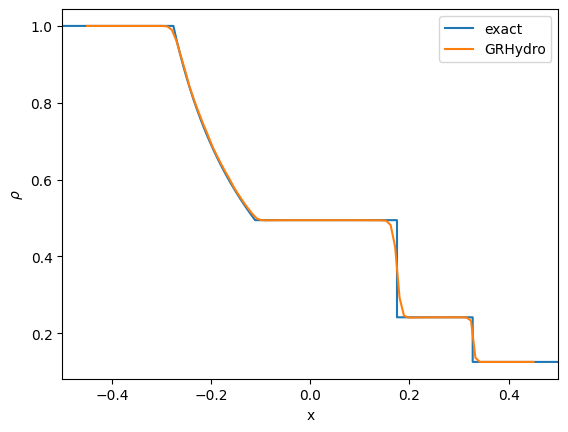

In [70]:
plt.plot(x_exact, rho_exact, label="exact")
plt.plot(*rho_final_800.coordinates_meshgrid(), rho_final_800.data_xyz, label="GRHydro")
plt.xlabel('x')
plt.ylabel(r'$\rho$')
plt.xlim(-0.5, 0.5)
#plt.ylim(0.1, 0.3)
plt.legend()
plt.show()

## Alternative Method
This method can only be used with simulations that used only one refinement level (i.e., a uniform grid) and using only 1 MPI process. The plot contains the real data, while using kuibit includes interpolation. Since we have only one refinement level, the two methods produce the same result.

In [71]:
#[iteration][refinement level][component number]
rho[0][0][0].data
rho_800[0][0][0].data

array([1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   ,

In [72]:
#rho_800[0][0][0].coordinates()[0].data

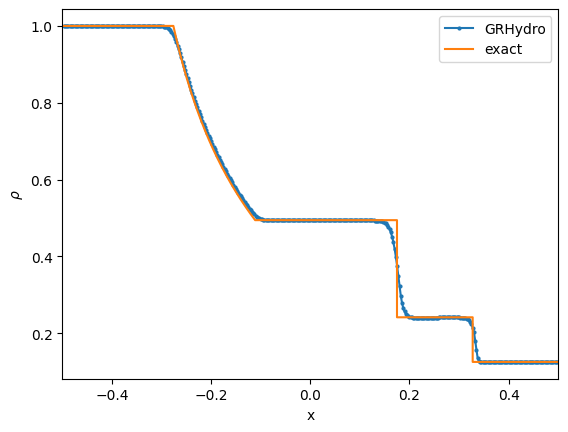

In [101]:
plt.plot(rho[200][0][0].coordinates()[0].data, rho[200][0][0].data, label="GRHydro", marker='o', markersize = 2)
plt.plot(x_exact, rho_exact, label="exact")
plt.xlabel('x')
plt.ylabel(r'$\rho$')
plt.xlim(-0.5, 0.5)
plt.legend()
plt.show()

## Comparing different resolutions
### Density

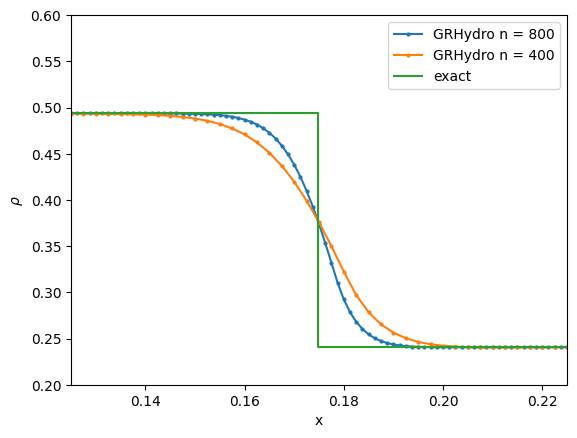

In [16]:
plt.plot(rho_800[400][0][0].coordinates()[0].data, rho_800[400][0][0].data, label="GRHydro n = 800", marker='o', markersize = 2)
plt.plot(rho[200][0][0].coordinates()[0].data, rho[200][0][0].data, label="GRHydro n = 400", marker='o', markersize = 2)
plt.plot(x_exact, rho_exact, label="exact")
plt.xlabel('x')
plt.ylabel(r'$\rho$')
plt.xlim(0.125, 0.225)
plt.ylim(0.2, 0.6)
plt.legend()
plt.show()

### Velocity

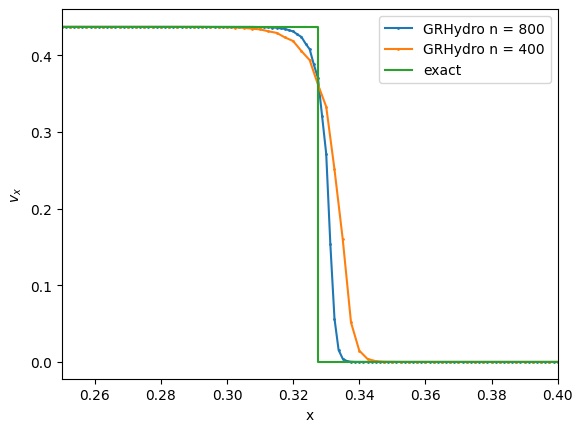

In [88]:
plt.plot(vx_800[400][0][0].coordinates()[0].data, vx_800[400][0][0].data, label="GRHydro n = 800", marker='o', markersize = 1)
plt.plot(vx[200][0][0].coordinates()[0].data, vx[200][0][0].data, label="GRHydro n = 400", marker='o', markersize = 1)
plt.plot(x_exact, vx_exact, label="exact")
plt.xlabel('x')
plt.ylabel(r'$v_x$')
plt.xlim(0.25, 0.4)
#plt.ylim(0.3, 0.5)
plt.legend()
plt.show()

### Pressure

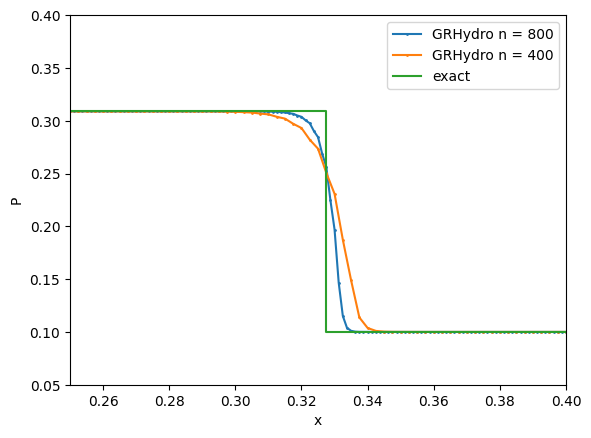

In [99]:
plt.plot(pres_800[400][0][0].coordinates()[0].data, pres_800[400][0][0].data, label="GRHydro n = 800", marker='o', markersize = 1)
plt.plot(pres[200][0][0].coordinates()[0].data, pres[200][0][0].data, label="GRHydro n = 400", marker='o', markersize = 1)
plt.plot(x_exact, press_exact, label="exact")
plt.xlabel('x')
plt.ylabel('P')
plt.xlim(0.25, 0.4)
plt.ylim(0.05, 0.4)
plt.legend()
plt.show()

# Initial Data plot

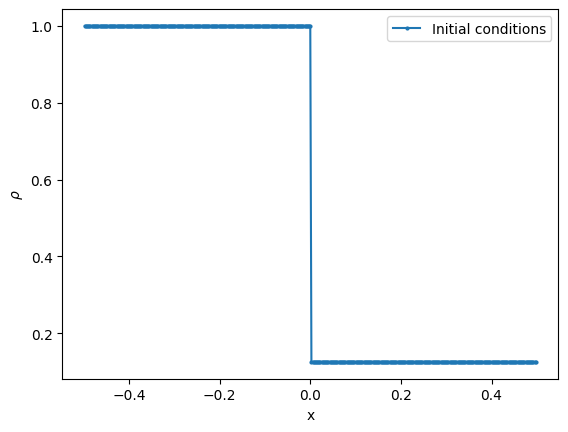

In [19]:
plt.plot(rho[0][0][0].coordinates()[0].data, rho[0][0][0].data, label="Initial conditions", marker='o', markersize = 2)
plt.xlabel('x')
plt.ylabel(r'$\rho$')
plt.legend()
plt.show()

In [24]:
pres=vars1d.fields.press

In [26]:
print(pres[0][0][0].data)

[1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0